In [1]:
import torch
import pde_model_sde
import viz

In [29]:
d = 2
seed = 42
dtype = torch.float32
device = None
gauss = pde_model_sde.GeneralGaussian(d, dtype=dtype, device=device)
Q = gauss.get_random_Q()

gamma = torch.tensor([1.0, 3.0])
gauss.set_gamma_Q(gamma, Q)
dist_inf = torch.distributions.MultivariateNormal(
    loc=torch.zeros(d, dtype=dtype, device=device),
    covariance_matrix=gauss.Sigma,
)

In [30]:
p = lambda X: torch.exp(dist_inf.log_prob(X[:,:-1]))

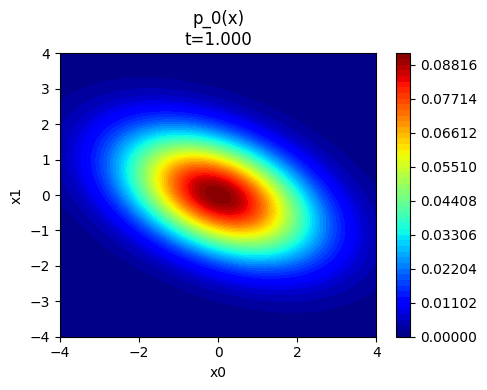

In [31]:
L = 4.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.5*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}
plotter = viz.FunctionPlotter(**options)
plotter.add_panel('ic', title="p_0(x)").heatmap(p)
plotter.show_plot(t_val=1.0)